# Lesson 8: Research Communities with Louvain

**Duration:** ~8 minutes 
**Module:** 5 - GDS with Python 
**Dataset:** Cora Citation Network (continued)

## What You'll Learn

- How to run Louvain community detection to find research communities
- How to analyze how detected communities relate to official subject labels
- How to combine community membership with centrality metrics
- How to interpret community statistics for influential and bridging communities

## Applying Louvain to Citations

You've already used Louvain in the fraud module to detect fraud rings. Now we'll apply the same algorithm to discover research communities—groups of papers that cite each other more than they cite papers outside the group.

The key question: do citation-based communities align with official subject labels?

## Quick Setup Check


In [4]:
import os
import pandas as pd
from IPython.display import display
from graphdatascience import GraphDataScience
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from pprint import pp

# Load credentials from .env
load_dotenv()
uri = os.getenv('NEO4J_URI')
username = os.getenv('NEO4J_USERNAME')
password = os.getenv('NEO4J_PASSWORD')

# Connect to GDS
gds = GraphDataScience(uri, auth=(username, password))

# Get the graph object
G = gds.graph.get("cora-graph")

print(f"Connected to GDS version: {gds.version()}")
print(f"Graph '{G.name()}' ready with {G.node_count():,} nodes")


Connected to GDS version: 2.25.0
Graph 'cora-graph' ready with 2,708 nodes


## Running Louvain Community Detection


In [18]:
# Run Louvain community detection
louvain_result = gds.louvain.write(
 G,
 writeProperty='louvainCommunity',
 maxLevels=10,
 maxIterations=10
)

print(f"Detected {louvain_result['communityCount']} communities")
print(f"Modularity score: {louvain_result['modularity']:.4f}")
print(f"Levels used: {louvain_result['ranLevels']}")


 Louvain:  12%|#1        | 11.92/100 [00:00<?, ?%/s]

Detected 102 communities
Modularity score: 0.8196
Levels used: 4


In [19]:
# Full result details (optional)
pp(dict(louvain_result))

{'modularity': np.float64(0.8196094827987788),
 'modularities': [0.5301094274789125,
                  0.7677985010606452,
                  0.8190403379027668,
                  0.8196094827987788],
 'ranLevels': np.int64(4),
 'communityCount': np.int64(102),
 'communityDistribution': {'p1': 2,
                           'max': 329,
                           'p5': 2,
                           'p90': 98,
                           'p50': 2,
                           'p95': 174,
                           'p10': 2,
                           'p75': 9,
                           'p99': 198,
                           'p25': 2,
                           'min': 2,
                           'mean': 26.54901960784314,
                           'p999': 329},
 'preProcessingMillis': np.int64(0),
 'computeMillis': np.int64(1280),
 'postProcessingMillis': np.int64(0),
 'writeMillis': np.int64(13),
 'nodePropertiesWritten': np.int64(2708),
 'configuration': {'maxIterations': 10,
           

**What just happened?**
- Louvain found natural communities in the citation network
- **Modularity** measures how well-defined the communities are (higher = better)
- The algorithm found communities of varying sizes

**Note:** The communities found may not match the official subject labels – they're based purely on citation patterns!


## What Do These Communities Mean?

We found communities based purely on citation patterns. But what do they represent?

The Cora dataset has official subject labels (Neural Networks, Theory, etc.) assigned by humans. By comparing Louvain's communities to these labels, we can see whether citation behavior follows topical boundaries—or reveals structure that formal labels miss.

## Analyzing Detected Communities

How do detected communities align with official subjects?


In [11]:
# Compare communities with subjects
q_community_subjects = """
MATCH (p:Paper)
WHERE p.louvainCommunity IS NOT NULL
WITH p.louvainCommunity AS community, 
 p.subject AS subject,
 count(*) AS count
RETURN community, subject, count
ORDER BY community, count DESC
LIMIT 20
"""

df_comm_subj = gds.run_cypher(q_community_subjects)
print("Community composition by subject:")
pp(df_comm_subj)


Community composition by subject:
    community                 subject  count
0         240              Case_Based      3
1         240      Genetic_Algorithms      2
2         289              Case_Based    111
3         289           Rule_Learning      4
4         289                  Theory      2
5         289         Neural_Networks      1
6         289      Genetic_Algorithms      1
7         326   Probabilistic_Methods     88
8         326         Neural_Networks     17
9         326  Reinforcement_Learning      7
10        326                  Theory      3
11        326           Rule_Learning      1
12        326              Case_Based      1
13        379           Rule_Learning      3
14        534              Case_Based     61
15        534         Neural_Networks      5
16        592         Neural_Networks      5
17        617         Neural_Networks      2
18        622         Neural_Networks    126
19        622   Probabilistic_Methods     14


In [12]:
# Get summary statistics for each community
q_community_stats = """
MATCH (p:Paper)
WHERE p.louvainCommunity IS NOT NULL
WITH p.louvainCommunity AS community,
 collect(DISTINCT p.subject) AS subjects,
 count(*) AS size,
 avg(p.pageRank) AS avg_pageRank,
 avg(p.betweenness) AS avg_betweenness
RETURN community, 
 size,
 size(subjects) AS num_subjects,
 subjects,
 avg_pageRank,
 avg_betweenness
ORDER BY size DESC
LIMIT 10
"""

df_community_stats = gds.run_cypher(q_community_stats)
print("\\nTop 10 Communities by Size:")
pp(df_community_stats)


\nTop 10 Communities by Size:
   community  size  num_subjects  \
0       1136   329             6   
1       2018   195             6   
2        686   182             6   
3        795   177             7   
4        745   172             5   
5        622   152             5   
6        640   145             5   
7       2614   127             6   
8        289   119             5   
9        326   117             6   

                                            subjects  avg_pageRank  \
0  [Genetic_Algorithms, Reinforcement_Learning, N...      1.016003   
1  [Reinforcement_Learning, Probabilistic_Methods...      1.065626   
2  [Case_Based, Theory, Rule_Learning, Neural_Net...      1.007886   
3  [Rule_Learning, Theory, Case_Based, Reinforcem...      0.984814   
4  [Genetic_Algorithms, Neural_Networks, Reinforc...      1.015722   
5  [Neural_Networks, Probabilistic_Methods, Theor...      0.993780   
6  [Theory, Reinforcement_Learning, Genetic_Algor...      1.006500   
7  [Rule_Lear

**Interpretation:**
- **Pure communities:** Dominated by one subject (tightly focused research area)
- **Mixed communities:** Span multiple subjects (interdisciplinary research)
- **High avg_pageRank:** Influential communities
- **High avg_betweenness:** Communities that bridge different areas

Communities reveal organizational structure beyond formal labels!


**Identifying key communities from these results:**
- **Most influential community:** Look for the highest `avg_pageRank`
- **Key bridging community:** Look for the highest `avg_betweenness`  
- **Most interdisciplinary:** Look for the highest `num_subjects`

Which communities stand out in your results?

## Visualizing Community Sizes

A bar chart helps us see the distribution of community sizes.

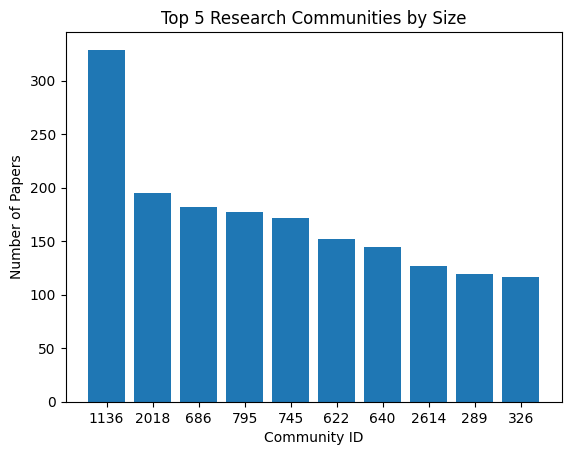

In [ ]:
q_community_sizes = """
    MATCH (p:Paper)
    WHERE p.louvainCommunity IS NOT NULL
    RETURN p.louvainCommunity AS community, 
           count(*) AS size
    ORDER BY size DESC
    LIMIT 10
"""

df_sizes = gds.run_cypher(q_community_sizes)

plt.bar(df_sizes['community'].astype(str), df_sizes['size'])
plt.xlabel('Community ID')
plt.ylabel('Number of Papers')
plt.title('Top 10 Research Communities by Size')
plt.show()

Find the most influential paper in each of the top 5 communities:

In [20]:
q = """
    MATCH (p:Paper)
    WHERE p.louvainCommunity IN [1136, 2018, 686, 795, 745]
    WITH p.louvainCommunity AS community, p
    ORDER BY p.pageRank DESC
    WITH community, collect(p)[0] AS topPaper
    RETURN community, topPaper.paper_Id, topPaper.pageRank
"""
gds.run_cypher(q)

,community,topPaper.paper_Id,topPaper.pageRank
0,1136,35,32.666616
1,745,1365,16.556646
2,2018,6213,13.710552
3,686,3231,7.331763
4,795,2440,6.488403


## Combining All Three Perspectives

You now have three complementary views of each paper:

- **PageRank** tells you how influential a paper is
- **Betweenness** tells you how much it connects different areas  
- **Community** tells you which cluster it belongs to

With all three metrics, you can answer questions like:
- Which paper is most influential in each community?
- Which papers bridge between communities?
- How do community-level averages compare across the network?

## Summary

In this lesson, you:

- Ran Louvain to detect 104 research communities from citation patterns
- Compared communities to official subject labels and found strong alignment
- Combined community membership with PageRank and Betweenness for richer analysis
- Identified influential and bridging communities using multi-metric analysis

**Next:** In Lesson 9, you'll use FastRP to create node embeddings, scale features for machine learning, and compute Node Similarity for recommendations.